In [41]:
import sys
!{sys.executable} -m pip install scikit-learn

In [42]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [44]:
df = pd.read_csv("players_20.csv")
df.head()

,sofifa_id,player_url,short_name,long_name,age,dob,height_cm,weight_kg,nationality,club,...,lwb,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb
0,158023,https://sofifa.com/player/158023/lionel-messi/...,L. Messi,Lionel Andrés Messi Cuccittini,32,1987-06-24,170,72,Argentina,FC Barcelona,...,68+2,66+2,66+2,66+2,68+2,63+2,52+2,52+2,52+2,63+2
1,20801,https://sofifa.com/player/20801/c-ronaldo-dos-...,Cristiano Ronaldo,Cristiano Ronaldo dos Santos Aveiro,34,1985-02-05,187,83,Portugal,Juventus,...,65+3,61+3,61+3,61+3,65+3,61+3,53+3,53+3,53+3,61+3
2,190871,https://sofifa.com/player/190871/neymar-da-sil...,Neymar Jr,Neymar da Silva Santos Junior,27,1992-02-05,175,68,Brazil,Paris Saint-Germain,...,66+3,61+3,61+3,61+3,66+3,61+3,46+3,46+3,46+3,61+3
3,200389,https://sofifa.com/player/200389/jan-oblak/20/...,J. Oblak,Jan Oblak,26,1993-01-07,188,87,Slovenia,Atlético Madrid,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,183277,https://sofifa.com/player/183277/eden-hazard/2...,E. Hazard,Eden Hazard,28,1991-01-07,175,74,Belgium,Real Madrid,...,66+3,63+3,63+3,63+3,66+3,61+3,49+3,49+3,49+3,61+3


In [45]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18278 entries, 0 to 18277
Columns: 104 entries, sofifa_id to rb
dtypes: float64(16), int64(45), object(43)
memory usage: 14.5+ MB


,sofifa_id,age,height_cm,weight_kg,overall,potential,value_eur,wage_eur,international_reputation,weak_foot,...,mentality_penalties,mentality_composure,defending_marking,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes
count,18278.000000,18278.000000,18278.000000,18278.000000,18278.000000,18278.000000,1.827800e+04,18278.000000,18278.000000,18278.000000,...,18278.000000,18278.000000,18278.000000,18278.000000,18278.000000,18278.000000,18278.000000,18278.000000,18278.000000,18278.000000
mean,219738.864482,25.283291,181.362184,75.276343,66.244994,71.546887,2.484038e+06,9456.942773,1.103184,2.944250,...,48.383357,58.528778,46.848889,47.640333,45.606631,16.572765,16.354853,16.212934,16.368038,16.709924
std,27960.200461,4.656964,6.756961,7.047744,6.949953,6.139669,5.585481e+06,21351.714095,0.378861,0.664656,...,15.708099,11.880840,20.091287,21.585641,21.217734,17.738069,16.996925,16.613665,17.136497,18.038125
min,768.000000,16.000000,156.000000,50.000000,48.000000,49.000000,0.000000e+00,0.000000,1.000000,1.000000,...,7.000000,12.000000,1.000000,5.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,204445.500000,22.000000,177.000000,70.000000,62.000000,67.000000,3.250000e+05,1000.000000,1.000000,3.000000,...,39.000000,51.000000,29.000000,27.000000,24.000000,8.000000,8.000000,8.000000,8.000000,8.000000
50%,226165.000000,25.000000,181.000000,75.000000,66.000000,71.000000,7.000000e+05,3000.000000,1.000000,3.000000,...,49.000000,60.000000,52.000000,55.000000,52.000000,11.000000,11.000000,11.000000,11.000000,11.000000
75%,240795.750000,29.000000,186.000000,80.000000,71.000000,75.000000,2.100000e+06,8000.000000,1.000000,3.000000,...,60.000000,67.000000,64.000000,66.000000,64.000000,14.000000,14.000000,14.000000,14.000000,14.000000
max,252905.000000,42.000000,205.000000,110.000000,94.000000,95.000000,1.055000e+08,565000.000000,5.000000,5.000000,...,92.000000,96.000000,94.000000,92.000000,90.000000,90.000000,92.000000,93.000000,91.000000,92.000000


In [46]:
df = df.fillna(method='ffill')

C:\Users\Dell\AppData\Local\Temp\ipykernel_6704\569672361.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')


In [47]:
df['PreferredFoot'] = df['preferred_foot'].map({'Left':0, 'Right':1})

df[['AttackWorkRate','DefenseWorkRate']] = df['work_rate'].str.split('/', expand=True)

mapping = {'Low':0, 'Medium':0.5, 'High':1}

df['AttackWorkRate'] = df['AttackWorkRate'].map(mapping)
df['DefenseWorkRate'] = df['DefenseWorkRate'].map(mapping)

## Top 10 Countries Analysis

From the graph, we can see that European countries dominate football.
Brazil and Argentina also contribute a high number of players.

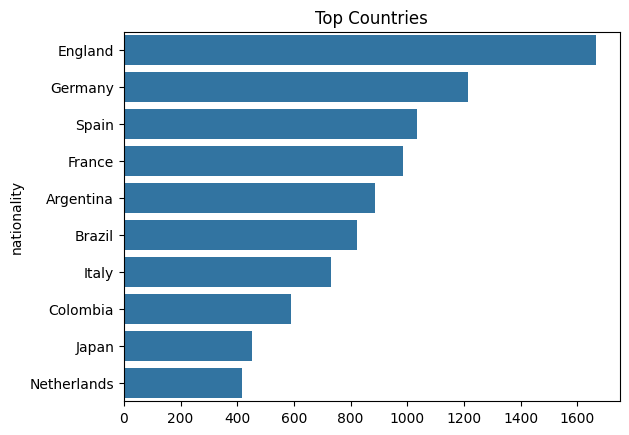

In [48]:
top_countries = df['nationality'].value_counts().head(10)

sns.barplot(x=top_countries.values, y=top_countries.index)
plt.title("Top Countries")
plt.show()

## Age vs Overall Rating

The graph shows that player performance increases until around age 27–30.
After this age, performance starts declining.

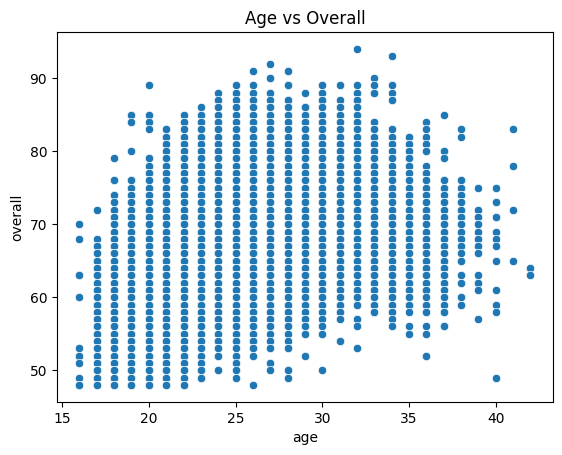

In [49]:
sns.scatterplot(x=df['age'], y=df['overall'])
plt.title("Age vs Overall")
plt.show()

In [50]:
attackers = df[df['player_positions'].str.contains('ST|RW|LW', na=False)]
attackers.groupby('player_positions')['wage_eur'].mean()

player_positions
CAM, CF, LW     2000.000000
CAM, CF, RW    11000.000000
CAM, CF, ST    20000.000000
CAM, CM, LW    46600.000000
CAM, CM, RW    22181.818182
                   ...     
ST, RW, LW      8269.230769
ST, RW, RB      3000.000000
ST, RW, RM     11444.444444
ST, RWB        15500.000000
ST, RWB, LM     6000.000000
Name: wage_eur, Length: 385, dtype: float64

In [51]:
features = [
 'pace','shooting','passing','dribbling','defending','physic',
 'attacking_finishing','attacking_short_passing',
 'movement_acceleration','movement_sprint_speed'
]

X = df[features]

In [52]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [53]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
labels = kmeans.fit_predict(X_scaled)

## Cluster Interpretation

Cluster 0: High shooting → Strikers  
Cluster 1: High passing → Midfielders  
Cluster 2: High defending → Defenders  
Cluster 3: High speed → Wingers  

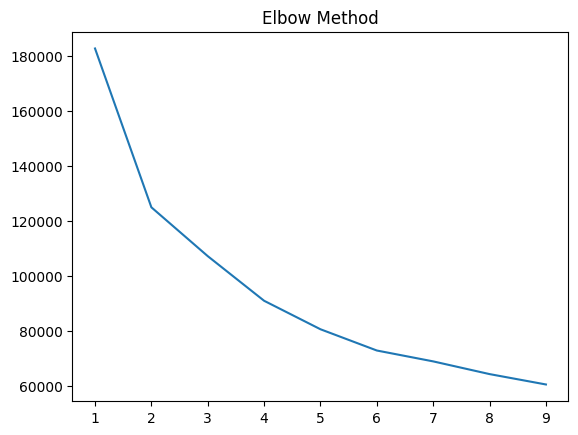

In [54]:
wcss = []

for i in range(1,10):
    km = KMeans(n_clusters=i)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.plot(range(1,10), wcss)
plt.title("Elbow Method")
plt.show()

In [55]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(n_clusters=4)
hc_labels = hc.fit_predict(X_scaled)

In [31]:
from sklearn.metrics import silhouette_score

print("KMeans:", silhouette_score(X_scaled, labels))
print("Hierarchical:", silhouette_score(X_scaled, hc_labels))

KMeans: 0.230846152791271
Hierarchical: 0.16104175110020283


## Model Comparison

KMeans performed better than Hierarchical Clustering based on silhouette score.
Hence, KMeans is selected for final model.

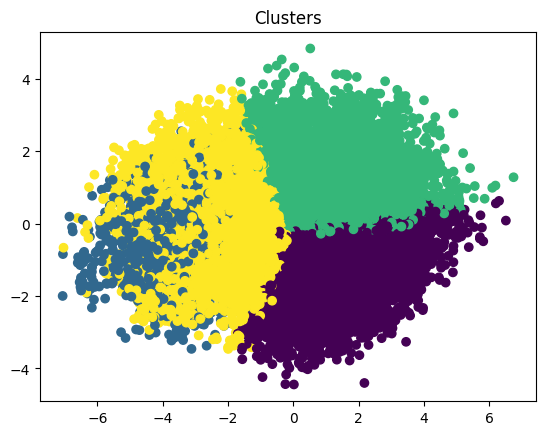

In [32]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1], c=labels)
plt.title("Clusters")
plt.show()

## Challenges Faced

- Handling missing values in dataset  
- Selecting important features for clustering  
- Scaling data before applying clustering  
- Choosing optimal number of clusters using Elbow method  
- Interpreting clusters meaningfully  